# Liquid validation/test evaluation

This notebook evaluates the S3D model on the liquid validation/test dataset used in the manuscript.

**Expected data layout**

```text
DATA_ROOT/
  ClassName_1/
    sample_001/
      frame_0001.jpg
      frame_0002.jpg
      ...
  ClassName_2/
    sample_002/
      frame_0001.jpg
      ...
```

Class labels are inferred from the sorted class-folder names under `DATA_ROOT`.

**Outputs**

The notebook saves the following files under `OUTPUT_DIR`:

- `predictions.csv`: per-sample true and predicted labels
- `metrics.json`: accuracy, class names, and key evaluation settings
- `confusion_matrix_counts.csv`: raw confusion matrix counts
- `confusion_matrix_percent.csv`: row-normalized confusion matrix percentages
- `confusion_matrix_percent.png`: plotted row-normalized confusion matrix

Update `DATA_ROOT` and `CHECKPOINT_PATH` in the configuration cell before running.


In [1]:
# Configuration

from pathlib import Path
import torch

# Project root. This works whether Jupyter is launched from the repository root
# or from inside the notebooks/ folder.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "FibTac_data" / "Liquid_test"
CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints" / "s3d_liquid.pth"
OUTPUT_DIR = PROJECT_ROOT / "results" / "liquid"

MAX_FRAMES = 300
BATCH_SIZE = 1          # Keep at 1 unless all samples have the same frame count.
PRELOAD = True
NUM_WORKERS = 0         # Keep at 0 for reproducibility and broad compatibility.
SEED = 42

# Preprocessing settings used for this task.
APPLY_YELLOW_DOT_MASK = True
CENTER_CROP_SIZE = 480
FRAME_SIZE = 224
CHANNEL_FIRST = True    # True for S3D input: [batch, channel, time, height, width]

# Yellow marker segmentation settings.
YELLOW_HSV_LOWER = (18, 60, 80)
YELLOW_HSV_UPPER = (60, 255, 255)
YELLOW_MIN_AREA = 5
YELLOW_BLUR_KSIZE = 5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Using device: {DEVICE}")


Using device: cuda


In [2]:
# Imports and reproducibility settings

import json
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision
from sklearn.metrics import accuracy_score, confusion_matrix
from torch.utils.data import DataLoader, Dataset

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [3]:
# Dataset and preprocessing utilities

def yellow_dot_mask(
    img_bgr,
    hsv_lower=YELLOW_HSV_LOWER,
    hsv_upper=YELLOW_HSV_UPPER,
    min_area=YELLOW_MIN_AREA,
    blur_ksize=YELLOW_BLUR_KSIZE,
):
    """Create a binary mask for yellow marker/dot regions in a BGR image."""
    if blur_ksize and blur_ksize > 1:
        img_bgr = cv2.GaussianBlur(img_bgr, (blur_ksize, blur_ksize), 0)

    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    lower = np.array(hsv_lower, dtype=np.uint8)
    upper = np.array(hsv_upper, dtype=np.uint8)
    mask_hsv = cv2.inRange(hsv, lower, upper)

    v = hsv[..., 2]
    v_eq = cv2.equalizeHist(v)
    _, mask_v = cv2.threshold(v_eq, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    mask = cv2.bitwise_and(mask_hsv, mask_v)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    clean = np.zeros_like(mask)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            clean[labels == i] = 255
    return clean


class ClassDataset(Dataset):
    """
    Dataset for folders of image-frame sequences.

    Each sample is one instance folder containing frame images. Class labels are
    inferred from the parent folder name. Frames are center-cropped, resized to
    224 x 224, scaled to [0, 1], and normalized to [-1, 1].
    """

    def __init__(
        self,
        root_dir,
        max_frames=300,
        preload=True,
        channel_first=True,
        apply_yellow_dot_mask=True,
        center_crop_size=480,
        frame_size=224,
    ):
        self.root_dir = Path(root_dir)
        self.max_frames = int(max_frames)
        self.channel_first = bool(channel_first)
        self.apply_yellow_dot_mask = bool(apply_yellow_dot_mask)
        self.center_crop_size = int(center_crop_size)
        self.frame_size = int(frame_size)

        self.class_map = {}
        self.paths = []
        self.labels = []
        self.data = []

        self._index_folders()

        if preload:
            self._preload_all()

    def _index_folders(self):
        if not self.root_dir.exists():
            raise FileNotFoundError(f"DATA_ROOT does not exist: {self.root_dir}")

        label_map = {}
        next_label = 0

        for class_folder in sorted(self.root_dir.iterdir()):
            if not class_folder.is_dir() or class_folder.name.startswith("."):
                continue

            if class_folder.name not in label_map:
                label_map[class_folder.name] = next_label
                self.class_map[next_label] = class_folder.name
                next_label += 1

            label = label_map[class_folder.name]

            for instance_folder in sorted(class_folder.iterdir()):
                if instance_folder.is_dir() and not instance_folder.name.startswith("."):
                    self.paths.append(instance_folder)
                    self.labels.append(label)

        if len(self.paths) == 0:
            raise ValueError(f"No sample folders were found under DATA_ROOT: {self.root_dir}")

    @staticmethod
    def _center_crop(img: np.ndarray, target_h: int, target_w: int) -> np.ndarray:
        h, w = img.shape[:2]
        ch = min(target_h, h)
        cw = min(target_w, w)
        y0 = (h - ch) // 2
        x0 = (w - cw) // 2
        return img[y0 : y0 + ch, x0 : x0 + cw]

    @staticmethod
    def _frame_paths(folder_path: Path):
        frame_paths = []
        for pattern in ("*.jpg", "*.jpeg", "*.png"):
            frame_paths.extend(folder_path.glob(pattern))
        return sorted(frame_paths)

    def _read_and_preprocess_frames(self, folder_path: Path) -> np.ndarray:
        frames = []

        for frame_path in self._frame_paths(folder_path):
            if self.apply_yellow_dot_mask:
                img_bgr = cv2.imread(str(frame_path), cv2.IMREAD_COLOR)
            else:
                img_gray = cv2.imread(str(frame_path), cv2.IMREAD_GRAYSCALE)
                img_bgr = None

            if self.apply_yellow_dot_mask:
                if img_bgr is None:
                    continue
                img_bgr = self._center_crop(img_bgr, self.center_crop_size, self.center_crop_size)
                img_bgr = cv2.resize(
                    img_bgr,
                    (self.frame_size, self.frame_size),
                    interpolation=cv2.INTER_LINEAR,
                )
                img = yellow_dot_mask(img_bgr)
            else:
                if img_gray is None:
                    continue
                img_gray = self._center_crop(img_gray, self.center_crop_size, self.center_crop_size)
                img = cv2.resize(
                    img_gray,
                    (self.frame_size, self.frame_size),
                    interpolation=cv2.INTER_LINEAR,
                )

            img = (img.astype(np.float32) / 255.0)[None, ...]  # [1, H, W]
            frames.append(img)

            if len(frames) >= self.max_frames:
                break

        if not frames:
            print(f"[WARNING] No valid frames in: {folder_path}")
            return np.zeros((1, 1, self.frame_size, self.frame_size), dtype=np.float32)

        return np.stack(frames, axis=0)  # [time, channel, height, width]

    def _preload_all(self):
        self.data = [self._read_and_preprocess_frames(path) for path in self.paths]

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        frames_np = self.data[idx] if self.data else self._read_and_preprocess_frames(self.paths[idx])
        label = int(self.labels[idx])
        folder = str(self.paths[idx])

        frames = torch.from_numpy(frames_np)
        frames = (frames - 0.5) / 0.5  # normalize to [-1, 1]

        if self.channel_first:
            frames = frames.permute(1, 0, 2, 3)  # [channel, time, height, width]

        return frames, label, folder


In [4]:
# Model definition

class S3D(nn.Module):
    def __init__(self, num_classes=10, in_ch=1):
        super().__init__()
        model = torchvision.models.video.s3d(weights=None)

        # Modify the first convolutional layers for single-channel input.
        model.features[0][0][0] = nn.Conv3d(
            in_ch,
            64,
            kernel_size=(1, 7, 7),
            stride=(1, 2, 2),
            padding=(0, 3, 3),
            bias=False,
        )
        model.features[0][1][0] = nn.Conv3d(
            64,
            64,
            kernel_size=(3, 1, 1),
            stride=(1, 1, 1),
            padding=(1, 0, 0),
            bias=False,
        )

        # Modify the classification head for the task-specific number of classes.
        in_channels = model.classifier[1].in_channels
        model.classifier[1] = nn.Conv3d(
            in_channels,
            num_classes,
            kernel_size=1,
            stride=1,
            bias=True,
        )

        self.model = model

    def forward(self, x):
        return self.model(x)


In [5]:
# Create dataset and dataloader

test_dataset = ClassDataset(
    root_dir=DATA_ROOT,
    max_frames=MAX_FRAMES,
    preload=PRELOAD,
    channel_first=CHANNEL_FIRST,
    apply_yellow_dot_mask=APPLY_YELLOW_DOT_MASK,
    center_crop_size=CENTER_CROP_SIZE,
    frame_size=FRAME_SIZE,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
)

class_names = [class_name for _, class_name in sorted(test_dataset.class_map.items())]

print(f"Number of samples: {len(test_dataset)}")
print(f"Classes: {class_names}")


Number of samples: 120
Classes: ['Dish_Liquid', 'Empty', 'Honey', 'Oil', 'Syrup', 'Water']


In [6]:
# Load checkpoint and run evaluation

def _strip_module_prefix(state_dict):
    """Remove 'module.' prefixes from DataParallel checkpoints when present."""
    return {
        key.replace("module.", "", 1) if key.startswith("module.") else key: value
        for key, value in state_dict.items()
    }


def _extract_state_dict(checkpoint):
    """Handle common checkpoint formats."""
    if isinstance(checkpoint, dict):
        for key in ("state_dict", "model_state_dict", "model"):
            value = checkpoint.get(key)
            if isinstance(value, dict):
                return value
    return checkpoint


def load_state_dict_safely(model, checkpoint_path, device):
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint file does not exist: {checkpoint_path}")

    try:
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
    except TypeError:
        # For older PyTorch versions that do not support weights_only.
        checkpoint = torch.load(checkpoint_path, map_location=device)

    state_dict = _extract_state_dict(checkpoint)
    state_dict = _strip_module_prefix(state_dict)

    try:
        model.load_state_dict(state_dict)
        return model
    except RuntimeError as first_error:
        # Some checkpoints may have been saved from the underlying torchvision S3D
        # module rather than from this wrapper class. In that case, add "model.".
        if isinstance(state_dict, dict) and all(not key.startswith("model.") for key in state_dict.keys()):
            prefixed_state_dict = {f"model.{key}": value for key, value in state_dict.items()}
            try:
                model.load_state_dict(prefixed_state_dict)
                return model
            except RuntimeError:
                pass
        raise first_error


def get_all_predictions(dataloader, model, device):
    model.eval()
    rows = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data, labels, folders in dataloader:
            data = data.to(device)
            labels = labels.to(device)

            outputs = model(data)
            if isinstance(outputs, (tuple, list)):
                outputs = outputs[0]

            predicted = outputs.argmax(dim=1)

            for folder, true_label, pred_label in zip(folders, labels.cpu().numpy(), predicted.cpu().numpy()):
                rows.append(
                    {
                        "sample_path": folder,
                        "sample_id": Path(folder).name,
                        "true_label_id": int(true_label),
                        "true_label": class_names[int(true_label)],
                        "predicted_label_id": int(pred_label),
                        "predicted_label": class_names[int(pred_label)],
                    }
                )

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels), pd.DataFrame(rows)


num_classes = len(class_names)
model = S3D(num_classes=num_classes, in_ch=1)
model = load_state_dict_safely(model, CHECKPOINT_PATH, DEVICE)
model = model.to(DEVICE)

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

pred_labels, true_labels, prediction_table = get_all_predictions(test_dataloader, model, DEVICE)

accuracy = accuracy_score(true_labels, pred_labels)
conf_matrix = confusion_matrix(true_labels, pred_labels, labels=np.arange(num_classes))

row_sums = conf_matrix.sum(axis=1, keepdims=True)
conf_matrix_percent = np.divide(
    conf_matrix.astype(float),
    row_sums,
    out=np.zeros_like(conf_matrix, dtype=float),
    where=row_sums != 0,
) * 100

prediction_table.to_csv(OUTPUT_DIR / "predictions.csv", index=False)
pd.DataFrame(conf_matrix, index=class_names, columns=class_names).to_csv(
    OUTPUT_DIR / "confusion_matrix_counts.csv"
)
pd.DataFrame(conf_matrix_percent, index=class_names, columns=class_names).to_csv(
    OUTPUT_DIR / "confusion_matrix_percent.csv"
)

metrics = {
    "task": "liquid",
    "accuracy": float(accuracy),
    "accuracy_percent": float(accuracy * 100.0),
    "num_samples": int(len(true_labels)),
    "num_classes": int(num_classes),
    "class_names": class_names,
    "data_root": str(DATA_ROOT),
    "checkpoint_path": str(CHECKPOINT_PATH),
    "max_frames": int(MAX_FRAMES),
    "batch_size": int(BATCH_SIZE),
    "preprocessing": {
        "apply_yellow_dot_mask": bool(APPLY_YELLOW_DOT_MASK),
        "yellow_hsv_lower": list(YELLOW_HSV_LOWER),
        "yellow_hsv_upper": list(YELLOW_HSV_UPPER),
        "yellow_min_area": int(YELLOW_MIN_AREA),
        "yellow_blur_ksize": int(YELLOW_BLUR_KSIZE),
        "center_crop_size": int(CENTER_CROP_SIZE),
        "frame_size": int(FRAME_SIZE),
        "normalize_mean": 0.5,
        "normalize_std": 0.5,
        "channel_first": bool(CHANNEL_FIRST),
    },
    "model": {
        "architecture": "torchvision.models.video.s3d",
        "weights": None,
        "input_channels": 1,
    },
}

with open(OUTPUT_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Saved results to: {OUTPUT_DIR}")


Accuracy: 97.50%
Saved results to: D:\GT\FibTac_github_release\results\liquid


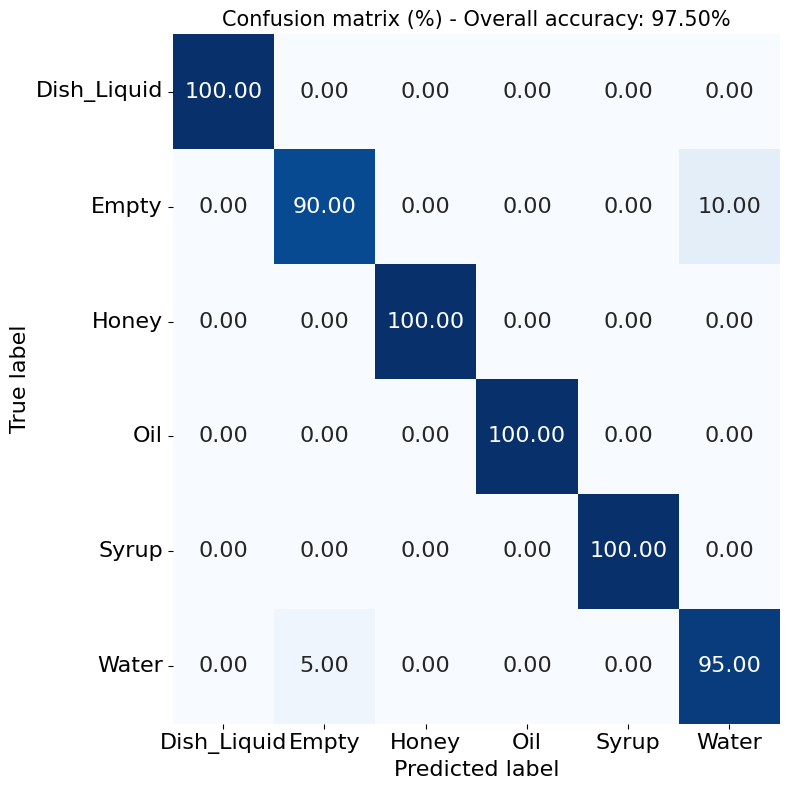

Saved figure to: D:\GT\FibTac_github_release\results\liquid\confusion_matrix_percent.png


In [7]:
# Plot and save the row-normalized confusion matrix

import seaborn as sns

figure_size = max(8, 0.8 * len(class_names))
plt.figure(figsize=(figure_size, figure_size))
sns.heatmap(
    conf_matrix_percent,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 16},
    cbar=False,
)

plt.xlabel("Predicted label", fontsize=16)
plt.ylabel("True label", fontsize=16)
plt.xticks(fontsize=16, rotation=0, ha="center")
plt.yticks(fontsize=16, rotation=0)
plt.title(f"Confusion matrix (%) - Overall accuracy: {accuracy * 100:.2f}%", fontsize=15)
plt.tight_layout()

figure_path = OUTPUT_DIR / "confusion_matrix_percent.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {figure_path}")
